# Line Emission Denoising — Full-Image U-Net

Per the 2026-06-18 mentor pivot: full-image denoising of line-emission velocity channels (NO patches), using the U-Net (DenoisingUNet), trained channel-by-channel.

**Continuum-subtraction variant (mentor, 2026-06-27):** Each channel has the static continuum removed first — the mean of the first/last CONTINUUM_N line-free channels is subtracted from every channel (dataset + evaluation), isolating the purely kinematics line emission.

Dataset: line-emission FITS cubes, (201, 600, 600), split at the cube level (3 RunID groups held out for inference only).
Channels sampled per cube via the Gaussian sampler (center 100, ~75% in [50,150]).
Each channel downsampled to 256×256, per-channel min-max normalised to [0,1].
Loss: HybridLoss(0.8, 0.2) = 0.8·MSE + 0.2·(1−SSIM). Optimizer Adam lr=1e-3.

### Kaggle setup
GPU on, Internet on, Add Input → your line-emission Dataset (FITS cubes). The bootstrap finds it under /kaggle/input/ and points the split at it.

## 0. Bootstrap (clone repo for src/, locate data)


In [1]:
import os, sys, subprocess, glob

ON_KAGGLE = os.path.exists('/kaggle')
if ON_KAGGLE:
    REPO='/kaggle/working/EXXA'; PKG=os.path.join(REPO,'DENOISING_DIFFUSION')
    if not os.path.exists(REPO):
        subprocess.run(['git','clone','--branch','line-emission','--depth','1','https://github.com/KrishanYadav333/EXXA.git',REPO], check=True)
    else:
        subprocess.run(['git','-C',REPO,'fetch','origin','line-emission'], check=True)
        subprocess.run(['git','-C',REPO,'reset','--hard','origin/line-emission'], check=True)
    # pytorch-msssim for the SSIM loss; bettermoments for moment-map evaluation (Sec. 9)
    subprocess.run([sys.executable,'-m','pip','install','-q','--no-deps','pytorch-msssim','bettermoments'], check=True)
    os.chdir(os.path.join(PKG,'notebooks'));  sys.path.insert(0, PKG)
    # find the line-emission data dir under /kaggle/input (contains run_* subfolders)
    hits = glob.glob('/kaggle/input/**/*_dirty.fits', recursive=True)
    DATA_DIR = os.path.dirname(os.path.dirname(hits[0])) if hits else None
else:
    if os.path.basename(os.getcwd()) != 'notebooks' and os.path.isdir('notebooks'): os.chdir('notebooks')
    sys.path.insert(0, os.path.abspath('..'))
    DATA_DIR = '../data/Line Emission Data'
print('cwd:', os.getcwd(), '| DATA_DIR:', DATA_DIR)

Cloning into '/kaggle/working/EXXA'...
Updating files: 100% (5061/5061), done.


cwd: /kaggle/working/EXXA/DENOISING_DIFFUSION/notebooks | DATA_DIR: /kaggle/input/datasets/krishanyadav333/line-emission-data/Line Emission Data


## 0b. Pull latest code (re-run anytime ├óΓé¼ΓÇ¥ NO kernel restart needed)

After I push new changes to the `line-emission` branch, just **re-run this one cell** to fetch them
and hot-reload the `src/` modules. Then re-run the import cell below. No "Restart & Run All" required.

In [2]:
# Pull latest from the line-emission branch and hot-reload src/ (no kernel restart).
# Self-contained: works even if the bootstrap cell hasn't run in this kernel.
import os, sys, subprocess

ON_KAGGLE = os.path.exists('/kaggle')
REPO = '/kaggle/working/EXXA'

if ON_KAGGLE and os.path.exists(REPO):
    subprocess.run(['git', '-C', REPO, 'fetch', 'origin', 'line-emission'], check=True)
    subprocess.run(['git', '-C', REPO, 'reset', '--hard', 'origin/line-emission'], check=True)
    print(subprocess.run(['git', '-C', REPO, 'log', '--oneline', '-1'],
                         capture_output=True, text=True).stdout.strip())
elif ON_KAGGLE:
    print('repo not cloned yet ├óΓé¼ΓÇ¥ run the bootstrap cell (0.) first')

# drop cached project modules so the next `import` picks up the freshly pulled code
for _m in [m for m in list(sys.modules) if m == 'src' or m.startswith('src.')]:
    del sys.modules[_m]
print('src.* cleared from module cache ├óΓé¼ΓÇ¥ now re-run the imports cell below.')

From https://github.com/KrishanYadav333/EXXA
 * branch            line-emission -> FETCH_HEAD


HEAD is now at c61d112 fix(data): add module-level continuum_of; misc notebook/results cleanup
c61d112 fix(data): add module-level continuum_of; misc notebook/results cleanup
src.* cleared from module cache ├óΓé¼ΓÇ¥ now re-run the imports cell below.


## 1. Imports, device, config


In [3]:
import time
import numpy as np
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

from src.data.cube_split import split_cubes
from src.data.fits_cube_dataset import FITSChannelDataset
from src.models.unet import DenoisingUNet
from src.utils.losses import HybridLoss
from pytorch_msssim import ssim as ssim_torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
N_GPU  = torch.cuda.device_count()
SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
print('device:', device, '| GPUs:', N_GPU,
      '->', [torch.cuda.get_device_name(i) for i in range(N_GPU)] if N_GPU else 'cpu')

TARGET_SIZE   = 256     # test 256 first; raise to 300 only if VRAM allows
N_SAMPLES     = 50      # channels per cube
EPOCHS        = 30
LR            = 1e-3
# Start big to fill the GPU(s); the probe below shrinks on OOM. On T4x2 (DataParallel)
# this is split across both cards (e.g. 32 -> 16 per GPU). On 1 GPU it auto-drops to fit.
BATCH_SIZE    = 32

device: cuda | GPUs: 2 -> ['Tesla T4', 'Tesla T4']


## 2. Cube-level split (3 RunID groups held out for inference only)


In [4]:
train_cubes, val_cubes, holdout_cubes = split_cubes(data_dir=DATA_DIR, n_holdout=3,
                                                     val_fraction=0.2, seed=SEED)

CUBE-LEVEL SPLIT (grouped by RunID — no channel-level leakage)
  data_dir          : /kaggle/input/datasets/krishanyadav333/line-emission-data/Line Emission Data
  total cubes       : 14  across 11 distinct RunIDs
  seed=42  n_holdout=3  val_fraction=0.2
----------------------------------------------------------------------
  TRAIN   :  7 cubes | RunIDs ['0006', '0010', '0020', '0022', '0030', '0035']
  VAL     :  2 cubes | RunIDs ['0016', '0036']
  HOLDOUT :  5 cubes | RunIDs ['0002', '0025', '0026']  <-- inference only, NEVER trained/validated
----------------------------------------------------------------------
  HOLDOUT cube folders (reserved for moment-map evaluation):
    - run_0002_00560_rt_00
    - run_0002_00560_rt_01
    - run_0002_00560_rt_04
    - run_0025_01000_rt_04
    - run_0026_00005_rt_04


## 3. Datasets + DataLoaders (full-image 256x256, per-channel norm)


In [5]:
SUBTRACT_CONTINUUM = True     # <-- the only switch vs notebook 05; subtract line-free continuum
CONTINUUM_N        = 5        # channels at each end averaged for the continuum estimate
train_ds = FITSChannelDataset(train_cubes, n_samples=N_SAMPLES, target_size=TARGET_SIZE, seed=SEED,
                              subtract_continuum=SUBTRACT_CONTINUUM, continuum_n=CONTINUUM_N)
val_ds   = FITSChannelDataset(val_cubes,   n_samples=N_SAMPLES, target_size=TARGET_SIZE, seed=SEED,
                              subtract_continuum=SUBTRACT_CONTINUUM, continuum_n=CONTINUUM_N)
print('train items:', len(train_ds), '| val items:', len(val_ds))

def make_loaders(bs):
    nw = 4 if ON_KAGGLE else 0   # FITS I/O is the bottleneck; more workers help a lot on Kaggle
    return (DataLoader(train_ds, batch_size=bs, shuffle=True,  num_workers=nw, pin_memory=True),
            DataLoader(val_ds,   batch_size=bs, shuffle=False, num_workers=nw, pin_memory=True))
train_loader, val_loader = make_loaders(BATCH_SIZE)

[FITSChannelDataset] 7 cubes x ~50 channels = 350 items | target 256x256 | continuum-subtracted (mean of first/last 5 channels)
[FITSChannelDataset] 2 cubes x ~50 channels = 100 items | target 256x256 | continuum-subtracted (mean of first/last 5 channels)
train items: 350 | val items: 100


## 4. Model ├óΓé¼ΓÇ¥ DenoisingUNet (last week's architecture, full image; t=0, sigmoid output)


In [6]:
model = DenoisingUNet(str(device))
print('DenoisingUNet params:', f'{sum(p.numel() for p in model.parameters()):,}')
with torch.no_grad():
    o = model(torch.randn(1,1,TARGET_SIZE,TARGET_SIZE,device=device),
              torch.zeros(1,dtype=torch.long,device=device))
print('forward (1,1,%d,%d) -> %s' % (TARGET_SIZE, TARGET_SIZE, tuple(o.shape)))

DenoisingUNet params: 3,424,065
forward (1,1,256,256) -> (1, 1, 256, 256)


## 5. Train ├óΓé¼ΓÇ¥ 30 epochs, HybridLoss, Adam lr=1e-3

**Multi-GPU:** if more than one GPU is visible (Kaggle **T4 x2**), the model is wrapped in
`nn.DataParallel`, so each batch is split across both cards. Checkpoints are saved from the
*unwrapped* model, so they load fine on a single GPU later.

If the chosen batch OOMs at 256, the probe **reduces batch size first** (32->16->8...), keeping the
image at 256 ├óΓé¼ΓÇ¥ never shrinking resolution before batch. The batch actually used is printed.

In [7]:
criterion = HybridLoss(alpha=0.8, beta=0.2)

def core(m):
    """Unwrapped model (for state_dict / portable checkpoints)."""
    return m.module if isinstance(m, torch.nn.DataParallel) else m

def build_model_opt():
    m = DenoisingUNet(str(device))
    if N_GPU > 1:                      # use BOTH T4s
        m = torch.nn.DataParallel(m)
    return m, torch.optim.Adam(m.parameters(), lr=LR)

# OOM-safe batch probe (256px fixed; shrink batch only, never resolution)
def probe_batch(bs0):
    bs = bs0
    while bs >= 1:
        try:
            m, opt = build_model_opt()
            tl, _ = make_loaders(bs)
            d, c = next(iter(tl)); d, c = d.to(device), c.to(device)
            t = torch.zeros(d.size(0), dtype=torch.long, device=device)
            loss = criterion(m(d, t), c)[0]
            loss.backward()
            del m, opt, loss, d, c; torch.cuda.empty_cache()
            return bs
        except RuntimeError as e:
            if 'out of memory' not in str(e).lower(): raise
            torch.cuda.empty_cache(); bs //= 2
            print(f'[OOM] reducing batch -> {bs} (image stays {TARGET_SIZE})')
    raise RuntimeError('does not fit even at batch 1')

BATCH_USED = probe_batch(BATCH_SIZE)
gpu_note = f'DataParallel x{N_GPU} (~{BATCH_USED // N_GPU}/GPU)' if N_GPU > 1 else f'single GPU'
print(f'BATCH SIZE USED: {BATCH_USED} at {TARGET_SIZE}x{TARGET_SIZE}  [{gpu_note}]')
train_loader, val_loader = make_loaders(BATCH_USED)

BATCH SIZE USED: 32 at 256x256  [DataParallel x2 (~16/GPU)]


In [8]:
model, optimizer = build_model_opt()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

CKPT = '../results/checkpoints/unet_line_emission_continuum_best.pth'
os.makedirs(os.path.dirname(CKPT), exist_ok=True)
best_val, best_epoch, best_state = float('inf'), -1, None
tr_hist, va_hist = [], []

hdr = f"{'ep':>3} | {'tr_tot':>8} {'tr_mse':>8} {'tr_ssim':>8} | {'va_tot':>8} {'va_mse':>8} {'va_ssim':>8} | {'lr':>8}"
print(hdr); print('-'*len(hdr))

def run_epoch(loader, train):
    model.train(train)
    tot=mse=ssl=0.0; n=0
    torch.set_grad_enabled(train)
    for d, c in loader:
        d, c = d.to(device), c.to(device)
        t = torch.zeros(d.size(0), dtype=torch.long, device=device)
        pred = model(d, t)          # DataParallel splits the batch across GPUs
        total, m, s = criterion(pred, c)
        if train:
            optimizer.zero_grad(); total.backward(); optimizer.step()
        bs=d.size(0); tot+=total.item()*bs; mse+=m.item()*bs; ssl+=s.item()*bs; n+=bs
    torch.set_grad_enabled(True)
    return tot/n, mse/n, ssl/n

for ep in range(1, EPOCHS+1):
    t0=time.time()
    tr=run_epoch(train_loader, True)
    va=run_epoch(val_loader, False)
    scheduler.step(va[0]); tr_hist.append(tr[0]); va_hist.append(va[0])
    mark=''
    if va[0] < best_val:
        best_val, best_epoch = va[0], ep
        # save the UNWRAPPED state_dict (no 'module.' prefix -> loads on single GPU later)
        best_state={k:v.clone() for k,v in core(model).state_dict().items()}
        torch.save({'epoch':ep,'model_state_dict':best_state,'val_loss':best_val,
                    'alpha':0.8,'beta':0.2,'arch':'DenoisingUNet','target_size':TARGET_SIZE,
                    'batch_size':BATCH_USED}, CKPT)
        mark=' *best'
    print(f"{ep:>3} | {tr[0]:>8.4f} {tr[1]:>8.4f} {tr[2]:>8.4f} | "
          f"{va[0]:>8.4f} {va[1]:>8.4f} {va[2]:>8.4f} | {optimizer.param_groups[0]['lr']:>8.1e}"
          f"  {time.time()-t0:.0f}s{mark}")

print(f'\nbest val total {best_val:.4f} @ epoch {best_epoch}; checkpoint -> {CKPT}')
if best_state: core(model).load_state_dict(best_state)

 ep |   tr_tot   tr_mse  tr_ssim |   va_tot   va_mse  va_ssim |       lr
------------------------------------------------------------------------
  1 |   0.1171   0.0661   0.3213 |   0.0290   0.0119   0.0974 |  1.0e-03  17s *best
  2 |   0.0208   0.0088   0.0687 |   0.0230   0.0102   0.0744 |  1.0e-03  12s *best
  3 |   0.0141   0.0051   0.0499 |   0.0185   0.0064   0.0669 |  1.0e-03  12s *best
  4 |   0.0139   0.0039   0.0542 |   0.0125   0.0038   0.0472 |  1.0e-03  12s *best
  5 |   0.0107   0.0030   0.0416 |   0.0107   0.0032   0.0405 |  1.0e-03  12s *best
  6 |   0.0084   0.0023   0.0329 |   0.0085   0.0023   0.0334 |  1.0e-03  13s *best
  7 |   0.0067   0.0020   0.0256 |   0.0077   0.0021   0.0300 |  1.0e-03  14s *best
  8 |   0.0069   0.0020   0.0267 |   0.0073   0.0021   0.0283 |  1.0e-03  13s *best
  9 |   0.0065   0.0020   0.0245 |   0.0081   0.0022   0.0314 |  1.0e-03  14s
 10 |   0.0056   0.0017   0.0215 |   0.0065   0.0017   0.0255 |  1.0e-03  14s *best
 11 |   0.0052   0.0

## 6. Loss curve


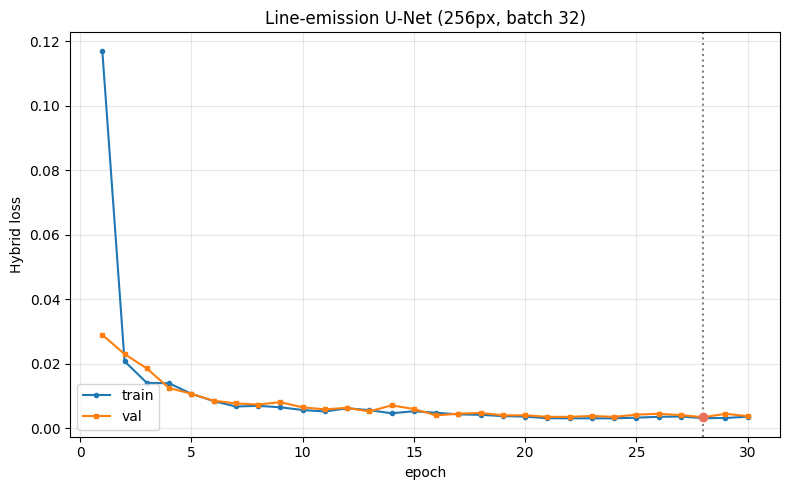

In [9]:
plt.figure(figsize=(8,5))
plt.plot(range(1,len(tr_hist)+1), tr_hist, marker='o', ms=3, label='train')
plt.plot(range(1,len(va_hist)+1), va_hist, marker='s', ms=3, label='val')
plt.axvline(best_epoch, color='gray', ls=':'); plt.scatter([best_epoch],[best_val],color='#E8715A',zorder=5)
plt.xlabel('epoch'); plt.ylabel('Hybrid loss'); plt.title(f'Line-emission U-Net ({TARGET_SIZE}px, batch {BATCH_USED})')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
os.makedirs('../results', exist_ok=True)
plt.savefig('../results/unet_line_emission_loss.png', dpi=140); plt.show()

## 7. Validation metrics ├óΓé¼ΓÇ¥ PSNR / SSIM / MSE


In [10]:
model.eval()
psnrs, ssims, mses = [], [], []
with torch.no_grad():
    for d, c in val_loader:
        d, c = d.to(device), c.to(device)
        t = torch.zeros(d.size(0), dtype=torch.long, device=device)
        pred = model(d, t).clamp(0,1)
        mse = torch.mean((pred-c)**2, dim=(1,2,3))
        psnrs += (10*torch.log10(1.0/torch.clamp(mse,min=1e-10))).cpu().tolist()
        ssims += ssim_torch(pred, c, data_range=1.0, size_average=False).cpu().tolist()
        mses  += mse.cpu().tolist()
print(f'Validation ({len(mses)} channels):  PSNR {np.mean(psnrs):.4f} dB | '
      f'SSIM {np.mean(ssims):.4f} | MSE {np.mean(mses):.6f}')

Validation (100 channels):  PSNR 32.9542 dB | SSIM 0.9857 | MSE 0.000681


## 8. Visualize 5 random validation channels ├óΓé¼ΓÇ¥ dirty | denoised | clean


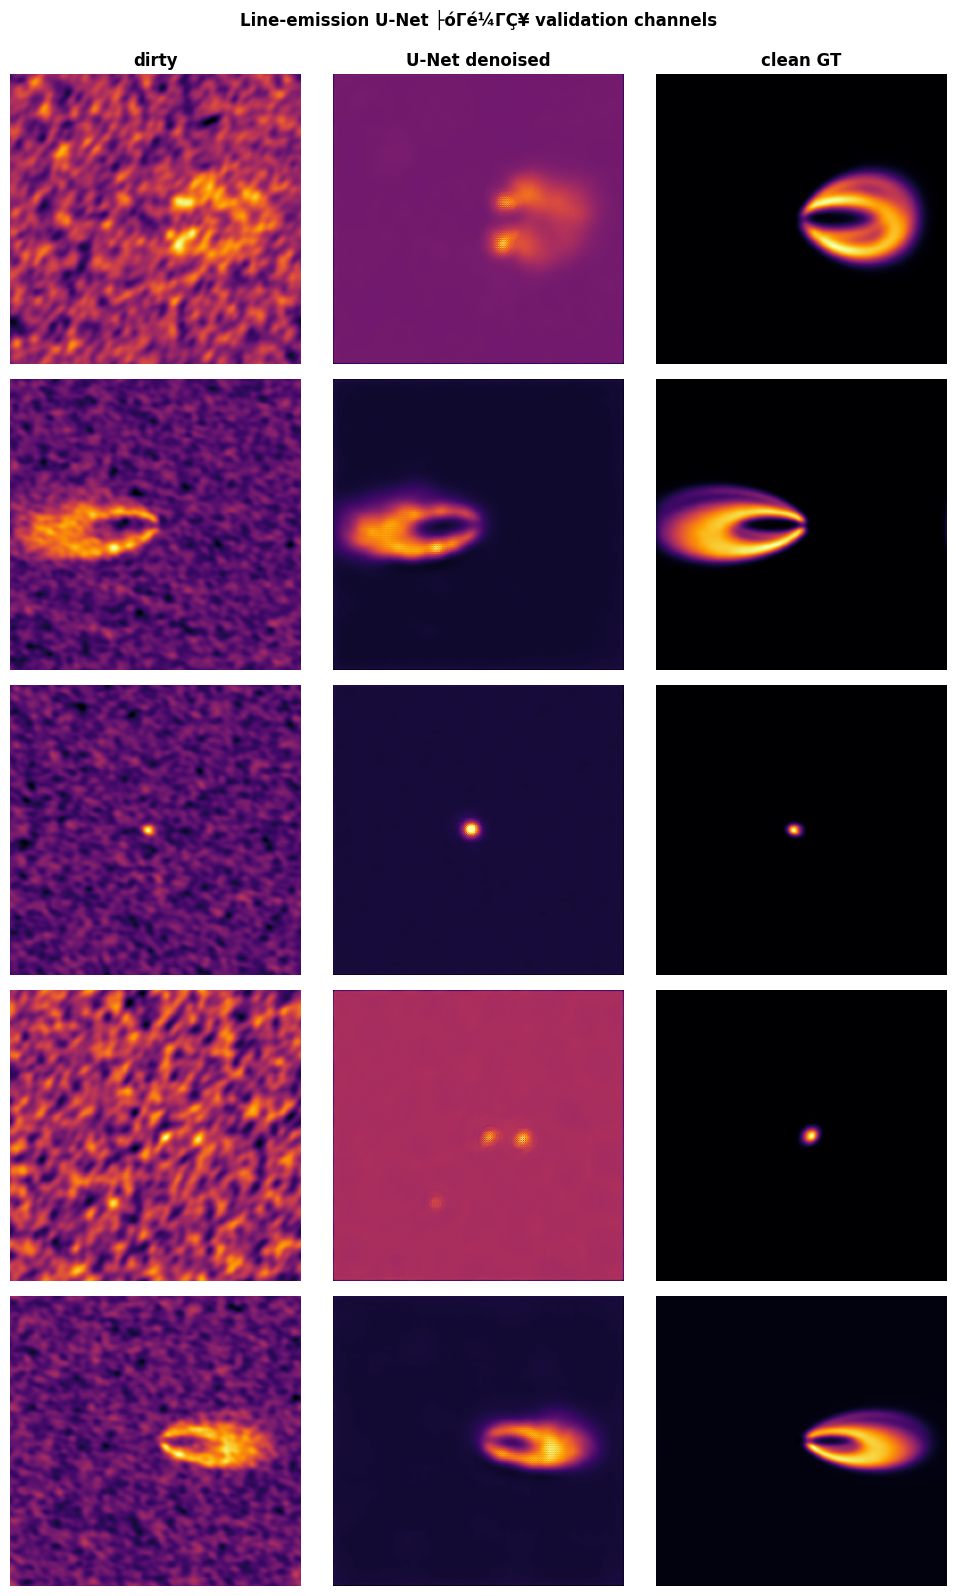

saved -> experiments/line_emission_unet_comparison.png


In [11]:
import random
idxs = random.Random(SEED).sample(range(len(val_ds)), 5)
fig, ax = plt.subplots(5, 3, figsize=(10, 16))
cols=['dirty','U-Net denoised','clean GT']
for k, t in enumerate(cols): ax[0,k].set_title(t, fontweight='bold')
model.eval()
with torch.no_grad():
    for r, ix in enumerate(idxs):
        d, c = val_ds[ix]
        t0 = torch.zeros(1, dtype=torch.long, device=device)
        pred = model(d[None].to(device), t0)[0,0].cpu().numpy()
        ci, ch = val_ds.index[ix]
        for col, im in enumerate([d[0].numpy(), pred, c[0].numpy()]):
            ax[r,col].imshow(np.clip(im,0,1), cmap='inferno'); ax[r,col].axis('off')
        ax[r,0].set_ylabel(f'{val_ds.cube_paths[ci][2]}\nch {ch}', fontsize=8)
fig.suptitle('Line-emission U-Net ├óΓé¼ΓÇ¥ validation channels', fontweight='bold', y=0.995)
plt.tight_layout()
os.makedirs('../experiments', exist_ok=True)
plt.savefig('../experiments/line_emission_unet_comparison.png', dpi=140); plt.show()
print('saved -> experiments/line_emission_unet_comparison.png')

## 9. Moment maps on a held-out cube (scientific evaluation target)

Moment maps are the real scientific product (mentor). Here we generate Moment 0/1/2 for a
**held-out** cube's clean and dirty versions with `bettermoments`, to confirm the package works and
to set up the end-to-end test. The eventual goal: denoise every channel of a held-out cube, rebuild
it, and show the **denoised** moment maps recover the clean kinematics (M1/M2) from the dirty ones.

held-out cube: run_0002_00560_rt_00


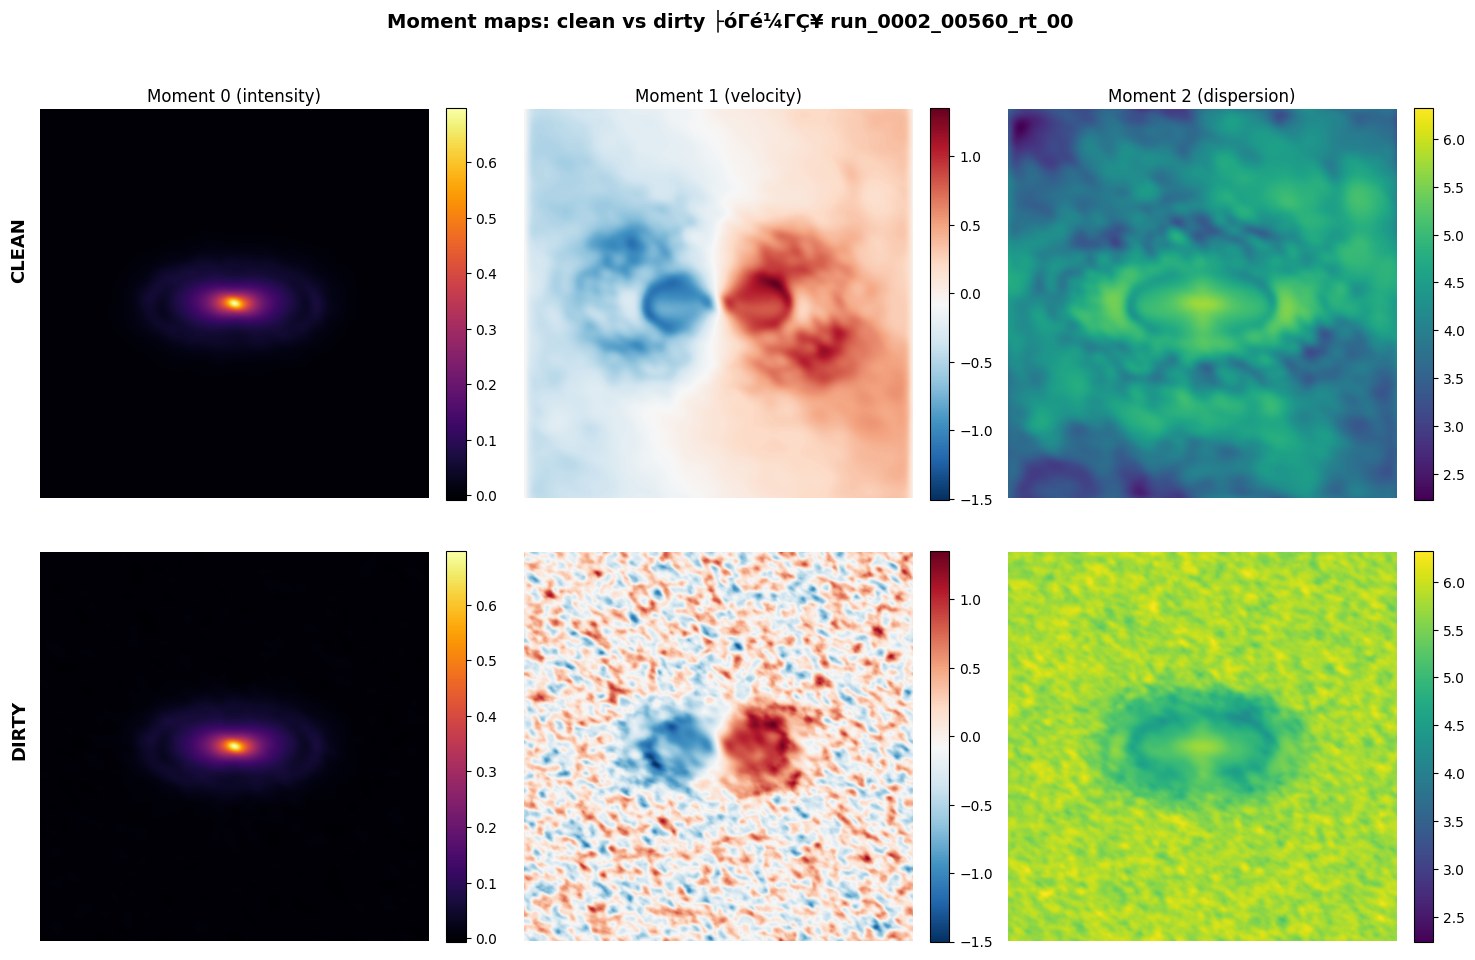

M0: mean|diff| 0.001429 (0.2% of clean max)
M1: mean|diff| 0.3755 (27.8% of clean max)
M2: mean|diff| 1.476 (25.8% of clean max)


In [12]:
from src.evaluation.moment_maps import generate_moment_maps

# pick a held-out cube (inference-only) and its clean/dirty FITS
ho = holdout_cubes[0]
print('held-out cube:', ho['folder'])

c0, c1, c2 = generate_moment_maps(ho['clean'])
d0, d1, d2 = generate_moment_maps(ho['dirty'])

names = ['Moment 0 (intensity)', 'Moment 1 (velocity)', 'Moment 2 (dispersion)']
cmaps = ['inferno', 'RdBu_r', 'viridis']
fig, ax = plt.subplots(2, 3, figsize=(15, 10))
for col, (cm, dm) in enumerate([(c0, d0), (c1, d1), (c2, d2)]):
    vmin = float(np.nanmin([np.nanmin(cm), np.nanmin(dm)]))
    vmax = float(np.nanmax([np.nanmax(cm), np.nanmax(dm)]))
    for row, m in [(0, cm), (1, dm)]:
        im = ax[row, col].imshow(m, origin='lower', cmap=cmaps[col], vmin=vmin, vmax=vmax)
        ax[row, col].axis('off'); fig.colorbar(im, ax=ax[row, col], fraction=0.046, pad=0.04)
    ax[0, col].set_title(names[col])
fig.text(0.02, 0.74, 'CLEAN', fontsize=13, fontweight='bold', rotation=90, va='center')
fig.text(0.02, 0.26, 'DIRTY', fontsize=13, fontweight='bold', rotation=90, va='center')
fig.suptitle(f"Moment maps: clean vs dirty ├óΓé¼ΓÇ¥ {ho['folder']}", fontweight='bold', fontsize=14)
plt.tight_layout(rect=[0.03, 0, 1, 0.97])
os.makedirs('../results', exist_ok=True)
plt.savefig('../results/moment_maps_holdout.png', dpi=140); plt.show()

for nm, cl, di in [('M0', c0, d0), ('M1', c1, d1), ('M2', c2, d2)]:
    diff = np.nanmean(np.abs(cl - di)); denom = np.nanmax(np.abs(cl)) or 1.0
    print(f'{nm}: mean|diff| {diff:.4g} ({100*diff/denom:.1f}% of clean max)')

## 10. End-to-end: denoise a full held-out cube -> moment-map recovery

The real scientific test. Take a **held-out** cube (never in train/val), denoise **every one of its
~201 channels** with the trained U-Net, reassemble a full 600x600 cube, and compare moment maps of
**clean vs dirty vs denoised**. If denoising worked, the denoised moment maps should be **closer to
clean than the dirty ones** (smaller mean|diff|), especially M1/M2 (the kinematics).

**Correctness notes:**
- **Per-channel un-normalization (no leakage):** each channel is min-max normalized to [0,1] by its
  *own dirty* (min,max) before the model; the [0,1] output is un-normalized with that **same
  per-channel (min,max)** ├óΓé¼ΓÇ¥ never a global cube min/max, never the clean cube's scale. The code below
  prints explicit confirmation.
- **Resolution:** the model only ever saw 256x256, so each denoised 600x600 channel is a 256x256
  prediction upsampled back up. The comparison is fair (clean/dirty/denoised all collapsed at 600x600),
  but the denoised output's *effective* resolution is lower than the data's native 600x600.
- `HOLDOUT_PICK` selects which held-out cube to use ├óΓé¼ΓÇ¥ try others to find one whose clean M1 shows a
  clear non-Keplerian **kink** (the planet signature in Jason's papers) for a stronger story.


In [13]:
import torch.nn.functional as F
from astropy.io import fits

CKPT = '../results/checkpoints/unet_line_emission_continuum_best.pth'
HOLDOUT_PICK = 0                      # change to try other held-out cubes (look for an M1 'kink')
ho = holdout_cubes[HOLDOUT_PICK]
CONTINUUM_N = 5                       # channels at each end for the continuum estimate (match dataset)
print('Held-out cube (never trained/validated):', ho['folder'])

# load trained weights into a fresh, unwrapped model -> robust across kernel restarts
ckpt = torch.load(CKPT, map_location=device)
infer_net = DenoisingUNet(str(device))
infer_net.load_state_dict(ckpt['model_state_dict'])
infer_net.eval()
print('loaded checkpoint: epoch', ckpt.get('epoch'), '| val_loss', round(float(ckpt.get('val_loss', float('nan'))), 4))

# full dirty cube, ALL channels (RAW, before continuum subtraction)
with fits.open(ho['dirty'], memmap=False) as hdul:
    dirty_cube_raw = np.ascontiguousarray(hdul[0].data).astype(np.float32)   # (C, 600, 600)
    dirty_hdr      = hdul[0].header.copy()
C, H, W = dirty_cube_raw.shape
print('cube shape:', dirty_cube_raw.shape)

# CONTINUUM SUBTRACTION (mentor): 2D continuum = mean of first/last N line-free channels,
# subtracted from EVERY channel -> isolates line emission. Same op the dataset applied in training.
def continuum_of(cube, n):
    n = max(1, min(n, C // 2))
    return np.concatenate([cube[:n], cube[C - n:]], axis=0).mean(axis=0)
dcont = continuum_of(dirty_cube_raw, CONTINUUM_N)
dirty_cube = dirty_cube_raw - dcont[None]        # line-only dirty (the model input)
print('continuum subtracted (mean of first/last', CONTINUUM_N, 'ch): dcont range',
      [round(float(dcont.min()), 6), round(float(dcont.max()), 6)])

# per-channel (min,max) FROM the continuum-subtracted DIRTY -> stored for un-normalization
los = dirty_cube.reshape(C, -1).min(axis=1)
his = dirty_cube.reshape(C, -1).max(axis=1)
rng = his - los
norm = np.zeros_like(dirty_cube)
nz = rng > 0
norm[nz] = (dirty_cube[nz] - los[nz, None, None]) / rng[nz, None, None]

# batched: 600 -> down 256 -> model -> up 600 -> un-normalize with the SAME per-channel (lo,hi)
denoised_cube = np.empty_like(dirty_cube)
BS = 32
with torch.no_grad():
    for s in range(0, C, BS):
        t = torch.from_numpy(norm[s:s+BS])[:, None].float().to(device)           # (b,1,600,600)
        t256 = F.interpolate(t, size=(TARGET_SIZE, TARGET_SIZE), mode='bilinear', align_corners=False)
        tz = torch.zeros(t256.size(0), dtype=torch.long, device=device)
        out = infer_net(t256, tz)                                                # linear (b,1,256,256)
        out600 = F.interpolate(out, size=(H, W), mode='bilinear', align_corners=False)[:, 0].cpu().numpy()
        for k in range(out600.shape[0]):
            ch = s + k
            denoised_cube[ch] = (out600[k] * rng[ch] + los[ch]) if rng[ch] > 0 else np.full((H, W), los[ch], np.float32)

print()
print('CONTINUUM + UN-NORMALIZATION:')
print('  continuum-subtracted (first/last', CONTINUUM_N, 'ch) BEFORE per-channel shared dirty-scale norm.')
print('  decoded denoised cube is line-only (continuum removed); decode uses each per-channel OWN')
print('  continuum-subtracted dirty (min,max) -> invertible, same scale the clean target used.')

# save denoised (line-only) cube with the ORIGINAL dirty header (correct velocity axis)
out_fits = '../results/denoised_cube_continuum.fits'
os.makedirs('../results', exist_ok=True)
fits.writeto(out_fits, denoised_cube.astype(np.float32), header=dirty_hdr, overwrite=True)
print()
print('saved denoised cube ->', out_fits, '| shape', denoised_cube.shape)

Held-out cube (never trained/validated): run_0002_00560_rt_00
loaded checkpoint: epoch 28 | val_loss 0.0034
cube shape: (201, 600, 600)
continuum subtracted (mean of first/last 5 ch): dcont range [-0.001651, 0.033307]

CONTINUUM + UN-NORMALIZATION:
  continuum-subtracted (first/last 5 ch) BEFORE per-channel shared dirty-scale norm.
  decoded denoised cube is line-only (continuum removed); decode uses each per-channel OWN
  continuum-subtracted dirty (min,max) -> invertible, same scale the clean target used.

saved denoised cube -> ../results/denoised_cube_continuum.fits | shape (201, 600, 600)


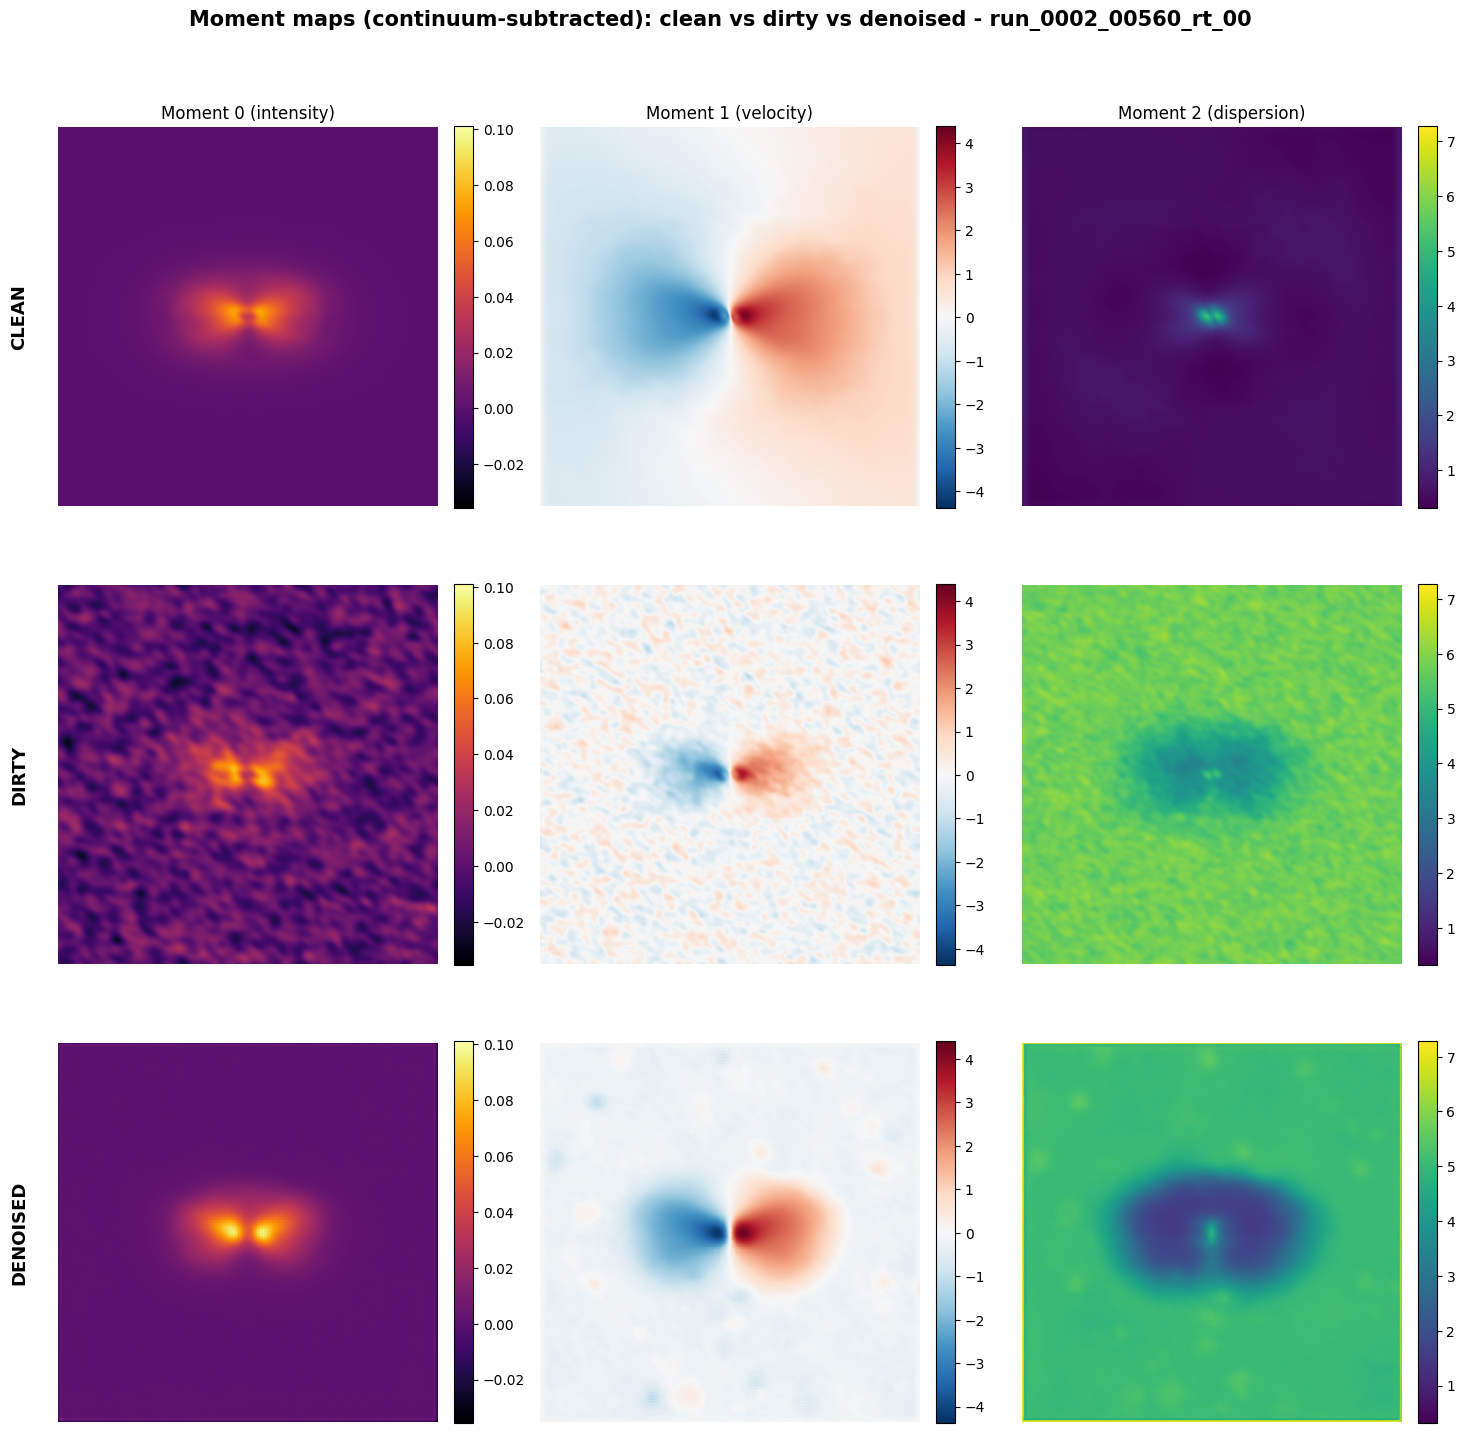


Held-out cube (CONTINUUM-SUBTRACTED): run_0002_00560_rt_00
moment    dirty-vs-clean   denoised-vs-clean   improvement
----------------------------------------------------------
M0             0.0064886           0.0011089         82.9%
M1               0.76992             0.62812         18.4%
M2                 5.017              4.1095         18.1%
(positive improvement = denoised moment map is closer to clean than dirty was)


In [14]:
import bettermoments as bm
from src.evaluation.moment_maps import generate_moment_maps

# Fair comparison: clean & dirty references are ALSO continuum-subtracted (line-only), like the
# denoised cube. velax shared from the dirty cube header.
_, velax = bm.load_cube(ho['dirty'])
with fits.open(ho['clean'], memmap=False) as h:
    clean_raw = np.ascontiguousarray(h[0].data).astype(np.float32)
ccont = continuum_of(clean_raw, CONTINUUM_N)
clean_csub = clean_raw - ccont[None]             # clean line-only (its OWN continuum)
dirty_csub = dirty_cube                          # already continuum-subtracted in the cell above

c0, c1, c2 = generate_moment_maps(None, data_velax=(clean_csub, velax))   # clean  (line-only)
d0, d1, d2 = generate_moment_maps(None, data_velax=(dirty_csub, velax))   # dirty  (line-only)
n0, n1, n2 = generate_moment_maps(out_fits)                               # denoised (line-only)

rows  = [('clean', (c0, c1, c2)), ('dirty', (d0, d1, d2)), ('denoised', (n0, n1, n2))]
names = ['Moment 0 (intensity)', 'Moment 1 (velocity)', 'Moment 2 (dispersion)']
cmaps = ['inferno', 'RdBu_r', 'viridis']

fig, ax = plt.subplots(3, 3, figsize=(15, 15))
for col in range(3):
    allcol = [rows[r][1][col] for r in range(3)]               # shared scale per column
    vmin = float(np.nanmin([np.nanmin(a) for a in allcol]))
    vmax = float(np.nanmax([np.nanmax(a) for a in allcol]))
    for r in range(3):
        im = ax[r, col].imshow(rows[r][1][col], origin='lower', cmap=cmaps[col], vmin=vmin, vmax=vmax)
        ax[r, col].axis('off'); fig.colorbar(im, ax=ax[r, col], fraction=0.046, pad=0.04)
    ax[0, col].set_title(names[col], fontsize=12)
for r, (lbl, _) in enumerate(rows):
    ax[r, 0].text(-0.08, 0.5, lbl.upper(), transform=ax[r, 0].transAxes, fontsize=13,
                  fontweight='bold', rotation=90, va='center', ha='right')
fig.suptitle('Moment maps (continuum-subtracted): clean vs dirty vs denoised - ' + ho['folder'],
             fontweight='bold', fontsize=15)
plt.tight_layout(rect=[0.02, 0, 1, 0.97])
plt.savefig('../results/moment_maps_continuum_comparison.png', dpi=140); plt.show()

# mean|diff| vs clean (finite overlap) for dirty and denoised, per moment
def mdiff(a, b):
    m = np.isfinite(a) & np.isfinite(b)
    return float(np.nanmean(np.abs(a[m] - b[m])))

print()
print('Held-out cube (CONTINUUM-SUBTRACTED):', ho['folder'])
hdr = '{:<8}{:>16}{:>20}{:>14}'.format('moment', 'dirty-vs-clean', 'denoised-vs-clean', 'improvement')
print(hdr); print('-' * 58)
for nm, cl, di, no in [('M0', c0, d0, n0), ('M1', c1, d1, n1), ('M2', c2, d2, n2)]:
    dd, nn = mdiff(cl, di), mdiff(cl, no)
    imp = 100 * (1 - nn / dd) if dd > 0 else float('nan')
    print('{:<8}{:>16.5g}{:>20.5g}{:>13.1f}%'.format(nm, dd, nn, imp))
print('(positive improvement = denoised moment map is closer to clean than dirty was)')

channel 100 - CONTINUUM-SUBTRACTED physical value ranges
  dirty    [-0.0052508, +0.016337]  mean +0.00022226  std 0.0017512
  denoised [-0.0017037, +0.019052]  mean +0.00014791  std 0.001126
  clean    [+3.1886e-06, +0.01655]  mean +0.00023305  std 0.00112
  ratio denoised_max/clean_max = 1.151   (~1 good; off = scale/overshoot)


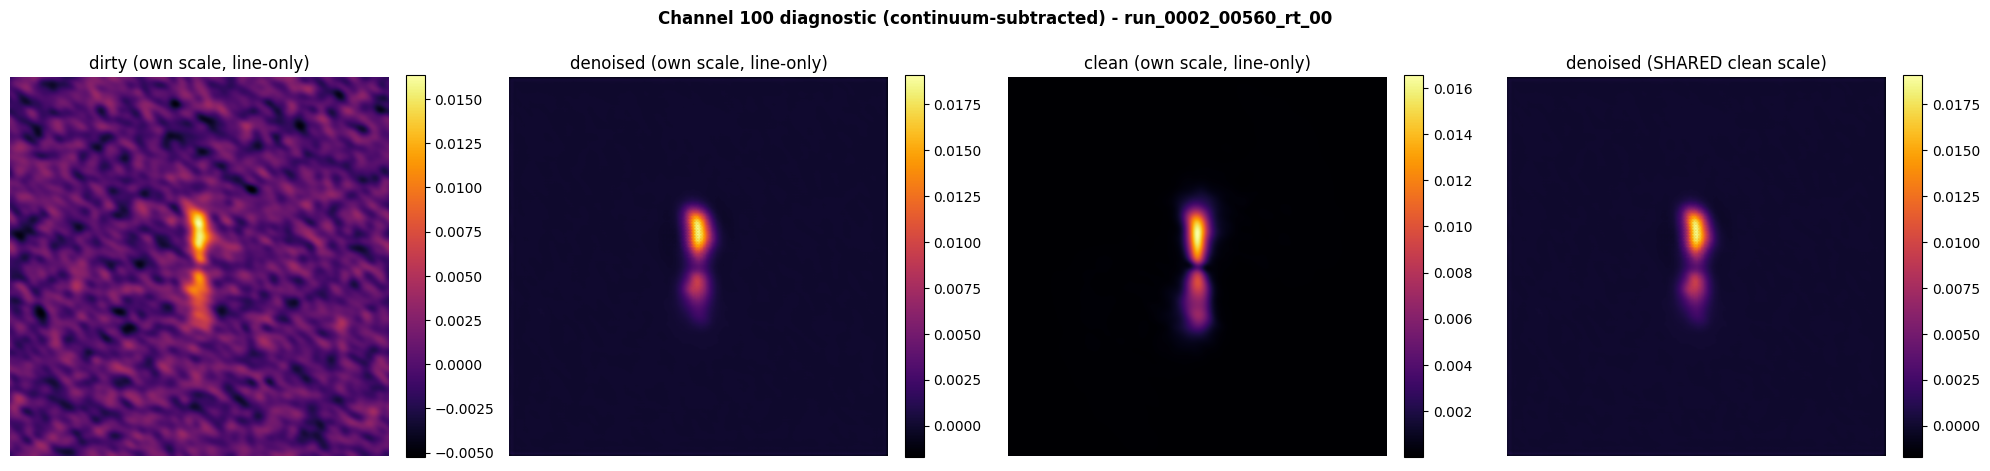

In [15]:
# --- DIAGNOSTIC: channel 100, dirty | denoised | clean, CONTINUUM-SUBTRACTED physical values ---
from astropy.io import fits
import numpy as np, matplotlib.pyplot as plt

CH = 100
with fits.open(ho['clean'], memmap=False) as h:
    clean_raw = np.ascontiguousarray(h[0].data).astype(np.float32)
ccont = continuum_of(clean_raw, CONTINUUM_N)
dch = dirty_cube_raw[CH] - dcont          # dirty line-only
cch = clean_raw[CH]      - ccont          # clean line-only
with fits.open(out_fits, memmap=False) as h:
    nch = np.asarray(h[0].data[CH], dtype=np.float32)   # denoised (already line-only)

def rng(x):
    return '[{:+.5g}, {:+.5g}]  mean {:+.5g}  std {:.5g}'.format(
        float(np.nanmin(x)), float(np.nanmax(x)), float(np.nanmean(x)), float(np.nanstd(x)))
print('channel', CH, '- CONTINUUM-SUBTRACTED physical value ranges')
print('  dirty   ', rng(dch))
print('  denoised', rng(nch))
print('  clean   ', rng(cch))
print('  ratio denoised_max/clean_max =',
      round(float(np.nanmax(nch) / (np.nanmax(cch) or 1)), 3), '  (~1 good; off = scale/overshoot)')

fig, ax = plt.subplots(1, 4, figsize=(20, 5))
for a, im, t in zip(ax[:3], [dch, nch, cch], ['dirty', 'denoised', 'clean']):
    p = a.imshow(im, origin='lower', cmap='inferno'); a.set_title(t + ' (own scale, line-only)'); a.axis('off')
    fig.colorbar(p, ax=a, fraction=0.046, pad=0.04)
vmin = float(min(np.nanmin(nch), np.nanmin(cch))); vmax = float(max(np.nanmax(nch), np.nanmax(cch)))
p = ax[3].imshow(nch, origin='lower', cmap='inferno', vmin=vmin, vmax=vmax)
ax[3].set_title('denoised (SHARED clean scale)'); ax[3].axis('off'); fig.colorbar(p, ax=ax[3], fraction=0.046, pad=0.04)
fig.suptitle('Channel ' + str(CH) + ' diagnostic (continuum-subtracted) - ' + ho['folder'], fontweight='bold')
plt.tight_layout(); plt.show()

## 11. All-5-Holdout Evaluation (Continuum-Subtracted)

Evaluate the continuum-subtracted checkpoint (`unet_line_emission_continuum_best.pth`) across **all 5 held-out cubes**
to get stable mean ± std for M0/M1/M2 improvement. No retraining — inference only.

Output: `results/moment_map_holdout_summary.csv` + summary bar chart with error bars.

Continuum checkpoint loaded: epoch 28 | val_loss 0.0034
Evaluating 5 held-out cubes...

cube                             dirty_M0    imp_M0%   dirty_M1    imp_M1%   dirty_M2    imp_M2%
------------------------------------------------------------------------------------------------
  denoising run_0002_00560_rt_00 ... done
run_0002_00560_rt_00             0.006489      82.9%     0.7699      18.4%      5.017      18.1%
  denoising run_0002_00560_rt_01 ... done
run_0002_00560_rt_01             0.004833      55.1%     0.4649      17.5%      5.343       8.4%
  denoising run_0002_00560_rt_04 ... done
run_0002_00560_rt_04             0.006434      79.8%     0.3272      15.3%      5.392      10.2%
  denoising run_0025_01000_rt_04 ... done
run_0025_01000_rt_04             0.004987      79.8%     0.6145      29.1%      4.907      44.1%
  denoising run_0026_00005_rt_04 ... done
run_0026_00005_rt_04             0.008393      51.6%      1.141       7.4%      3.534      19.6%

SUMMARY (n=5 cubes):
 

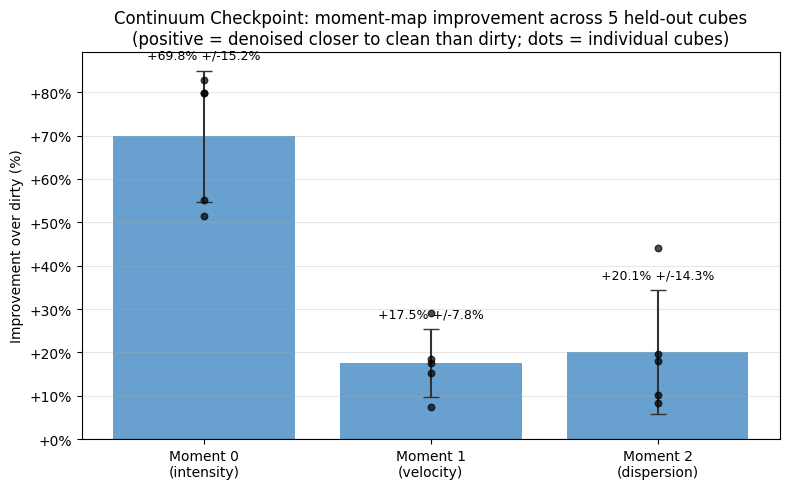

Chart saved -> ../results/moment_map_holdout_summary.png


In [16]:
import os, csv
import torch, torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import bettermoments as bm
from astropy.io import fits
from src.models.unet import DenoisingUNet
from src.evaluation.moment_maps import generate_moment_maps
from src.data.fits_cube_dataset import continuum_of

# ----- config -----
CKPT_CONT   = '../results/checkpoints/unet_line_emission_continuum_best.pth'
TARGET_SIZE = 256
BS          = 32
OUT_DIR     = '../results'
os.makedirs(OUT_DIR, exist_ok=True)

# load continuum checkpoint into a fresh unwrapped model
ckpt = torch.load(CKPT_CONT, map_location=device)
eval_net = DenoisingUNet(str(device))
eval_net.load_state_dict(ckpt['model_state_dict'])
eval_net.eval()
print('Continuum checkpoint loaded: epoch', ckpt.get('epoch'),
      '| val_loss', round(float(ckpt.get('val_loss', float('nan'))), 4))
print('Evaluating', len(holdout_cubes), 'held-out cubes...')

def mdiff(a, b):
    # Mean absolute pixel diff over finite pixels.
    mask = np.isfinite(a) & np.isfinite(b)
    return float(np.nanmean(np.abs(a[mask] - b[mask])))

def denoise_cube_continuum(ho_entry, net):
    # Load dirty cube, SUBTRACT CONTINUUM, denoise, save FITS.
    with fits.open(ho_entry['dirty'], memmap=False) as hdul:
        dirty_raw = np.ascontiguousarray(hdul[0].data).astype(np.float32)
        hdr = hdul[0].header.copy()
        
    C, H, W = dirty_raw.shape
    
    # 1. Measure and subtract continuum FIRST (just like in the Dataset)
    dcont = continuum_of(dirty_raw, CONTINUUM_N)
    dirty_csub = dirty_raw - dcont[None, :, :]
    
    # 2. Per-channel min-max normalization on the continuum-subtracted data
    los  = dirty_csub.reshape(C, -1).min(axis=1)
    his  = dirty_csub.reshape(C, -1).max(axis=1)
    rngs = his - los
    norm = np.zeros_like(dirty_csub)
    nz = rngs > 0
    norm[nz] = (dirty_csub[nz] - los[nz, None, None]) / rngs[nz, None, None]
    
    denoised_csub = np.empty_like(dirty_csub)
    with torch.no_grad():
        for s in range(0, C, BS):
            t = torch.from_numpy(norm[s:s+BS])[:, None].float().to(device)
            t256 = F.interpolate(t, (TARGET_SIZE, TARGET_SIZE), mode='bilinear', align_corners=False)
            tz   = torch.zeros(t256.size(0), dtype=torch.long, device=device)
            out  = net(t256, tz)
            out600 = F.interpolate(out, (H, W), mode='bilinear', align_corners=False)[:, 0].cpu().numpy()
            for k in range(out600.shape[0]):
                ch = s + k
                denoised_csub[ch] = (out600[k] * rngs[ch] + los[ch]) if rngs[ch] > 0 else \
                                np.full((H, W), los[ch], np.float32)
                                
    out_path = os.path.join(OUT_DIR, 'denoised_' + ho_entry['folder'] + '.fits')
    fits.writeto(out_path, denoised_csub.astype(np.float32), header=hdr, overwrite=True)
    return out_path, dirty_csub

# ----- main loop -----
rows_data = []
col_w = 30
hdr_line = '{:<{w}} {:>10} {:>10} {:>10} {:>10} {:>10} {:>10}'.format(
    'cube', 'dirty_M0', 'imp_M0%', 'dirty_M1', 'imp_M1%', 'dirty_M2', 'imp_M2%', w=col_w)
print('\n' + hdr_line)
print('-' * len(hdr_line))

for ho in holdout_cubes:
    print('  denoising', ho['folder'], '...', end=' ', flush=True)
    out_fits_ho, dirty_csub = denoise_cube_continuum(ho, eval_net)
    print('done')

    # Load clean and subtract its own continuum for a fair comparison
    with fits.open(ho['clean'], memmap=False) as h:
        clean_raw = np.ascontiguousarray(h[0].data).astype(np.float32)
    ccont = continuum_of(clean_raw, CONTINUUM_N)
    clean_csub = clean_raw - ccont[None]
    
    _, velax = bm.load_cube(ho['dirty'])

    c0, c1, c2 = generate_moment_maps(None, data_velax=(clean_csub, velax))
    d0, d1, d2 = generate_moment_maps(None, data_velax=(dirty_csub, velax))
    n0, n1, n2 = generate_moment_maps(out_fits_ho)

    row = {'cube': ho['folder']}
    for nm, cl, di, no in [('M0', c0, d0, n0), ('M1', c1, d1, n1), ('M2', c2, d2, n2)]:
        dd  = mdiff(cl, di)
        nn  = mdiff(cl, no)
        imp = 100.0 * (1 - nn / dd) if dd > 0 else float('nan')
        row['dirty_' + nm] = round(dd, 6)
        row['imp_'   + nm] = round(imp, 2)
    rows_data.append(row)

    print('{:<{w}} {:>10.4g} {:>9.1f}% {:>10.4g} {:>9.1f}% {:>10.4g} {:>9.1f}%'.format(
        ho['folder'],
        row['dirty_M0'], row['imp_M0'],
        row['dirty_M1'], row['imp_M1'],
        row['dirty_M2'], row['imp_M2'], w=col_w))

# ----- aggregate -----
moments = ['M0', 'M1', 'M2']
imps  = {m: [r['imp_' + m] for r in rows_data if not (r['imp_' + m] != r['imp_' + m])]
         for m in moments}   # NaN-safe
means = {m: float(np.mean(imps[m]))                              for m in moments}
stds  = {m: float(np.std(imps[m], ddof=1)) if len(imps[m]) > 1 else 0.0 for m in moments}

print('\n' + '=' * len(hdr_line))
print('SUMMARY (n=' + str(len(rows_data)) + ' cubes):')
for m in moments:
    print('  ' + m + ': mean {:+.1f}%  std {:.1f}%  (n={})'.format(means[m], stds[m], len(imps[m])))

# ----- save CSV -----
csv_path = os.path.join(OUT_DIR, 'moment_map_holdout_summary.csv')
fieldnames = ['cube', 'dirty_M0', 'imp_M0', 'dirty_M1', 'imp_M1', 'dirty_M2', 'imp_M2']
with open(csv_path, 'w', newline='') as cf:
    w = csv.DictWriter(cf, fieldnames=fieldnames)
    w.writeheader()
    for r in rows_data:
        w.writerow(r)
    w.writerow({'cube': 'MEAN',
                **{'imp_' + m: round(means[m], 2) for m in moments},
                **{'dirty_' + m: '' for m in moments}})
    w.writerow({'cube': 'STD',
                **{'imp_' + m: round(stds[m], 2) for m in moments},
                **{'dirty_' + m: '' for m in moments}})
print('\nCSV saved ->', csv_path)

# ----- bar chart -----
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(moments))
bar_means = [means[m] for m in moments]
bar_stds  = [stds[m]  for m in moments]
colors = ['#4E91C7' if v >= 0 else '#E8715A' for v in bar_means]
bars = ax.bar(x, bar_means, yerr=bar_stds, capsize=6, color=colors, alpha=0.85,
              error_kw=dict(elinewidth=1.5, ecolor='#333333'))
ax.axhline(0, color='#333333', lw=0.8, ls='--')
ax.set_xticks(x)
ax.set_xticklabels(['Moment 0\n(intensity)', 'Moment 1\n(velocity)', 'Moment 2\n(dispersion)'])
ax.set_ylabel('Improvement over dirty (%)')
ax.set_title('Continuum Checkpoint: moment-map improvement across 5 held-out cubes\n'
             '(positive = denoised closer to clean than dirty; dots = individual cubes)')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%+.0f%%'))
for bar, mv, sv in zip(bars, bar_means, bar_stds):
    ht = bar.get_height()
    va = 'bottom' if ht >= 0 else 'top'
    offset = (sv + 2) * (1 if ht >= 0 else -1)
    ax.text(bar.get_x() + bar.get_width()/2, ht + offset,
            '{:+.1f}% +/-{:.1f}%'.format(mv, sv),
            ha='center', va=va, fontsize=9)
for i, m in enumerate(moments):
    ax.scatter([i]*len(imps[m]), imps[m], color='k', s=22, zorder=5, alpha=0.7)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
chart_path = os.path.join(OUT_DIR, 'moment_map_holdout_summary.png')
plt.savefig(chart_path, dpi=140)
plt.show()
print('Chart saved ->', chart_path)
